
# Comparative Maize Disease Classification with Pretrained CNNs

**Programme**: Master of Science in Artificial Intelligence  
**Course**: CSA 809 Deep Learning  
**Name**: Marrion Kiprop Cherop  
**Module 10**: Resnet, Inception And Densenet  
**Reg Number**: ST62/80971/2024  


# 0. Introduction
This implementation uses the Kaggle **Five Crop Diseases Dataset** and compares:

- ResNet50
- InceptionV3
- DenseNet121

The maize subset is used with four classes:
Common Rust, Gray Leaf Spot, Healthy and Northern Leaf Blight.

Each network uses ImageNet pretrained weights and is evaluated using:
**validation loss, validation accuracy and weighted F1-score**.

## 1. Install and import libraries

In [ ]:

!pip -q install kagglehub

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Download dataset

In [ ]:

DATASET_ID = "shubham2703/five-crop-diseases-dataset"

dataset_path = kagglehub.dataset_download(DATASET_ID)

print("Dataset downloaded to:")
print(dataset_path)


100%|██████████| 4.33G/4.33G [00:51<00:00, 89.6MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/shubham2703/five-crop-diseases-dataset/versions/1


## 3. Locate maize/corn images

In [ ]:

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def get_maize_label(path):
    text = str(path).lower().replace("_", " ").replace("-", " ")

    if "corn" not in text and "maize" not in text:
        return None

    if "common rust" in text:
        return "Common Rust"
    elif "gray leaf spot" in text or "grey leaf spot" in text:
        return "Gray Leaf Spot"
    elif "northern leaf blight" in text or "leaf blight" in text:
        return "Northern Leaf Blight"
    elif "healthy" in text:
        return "Healthy"

    return None

records = []

for path in Path(dataset_path).rglob("*"):
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        label = get_maize_label(path)
        if label is not None:
            records.append({
                "filepath": str(path),
                "label": label
            })

df = pd.DataFrame(records)

print("Images found:", len(df))
print(df["label"].value_counts())

if len(df) == 0:
    raise ValueError(
        "No maize images found automatically. "
        "Inspect the downloaded folder structure."
    )


Images found: 3852
label
Common Rust             1192
Healthy                 1162
Northern Leaf Blight     985
Gray Leaf Spot           513
Name: count, dtype: int64


### Sample images

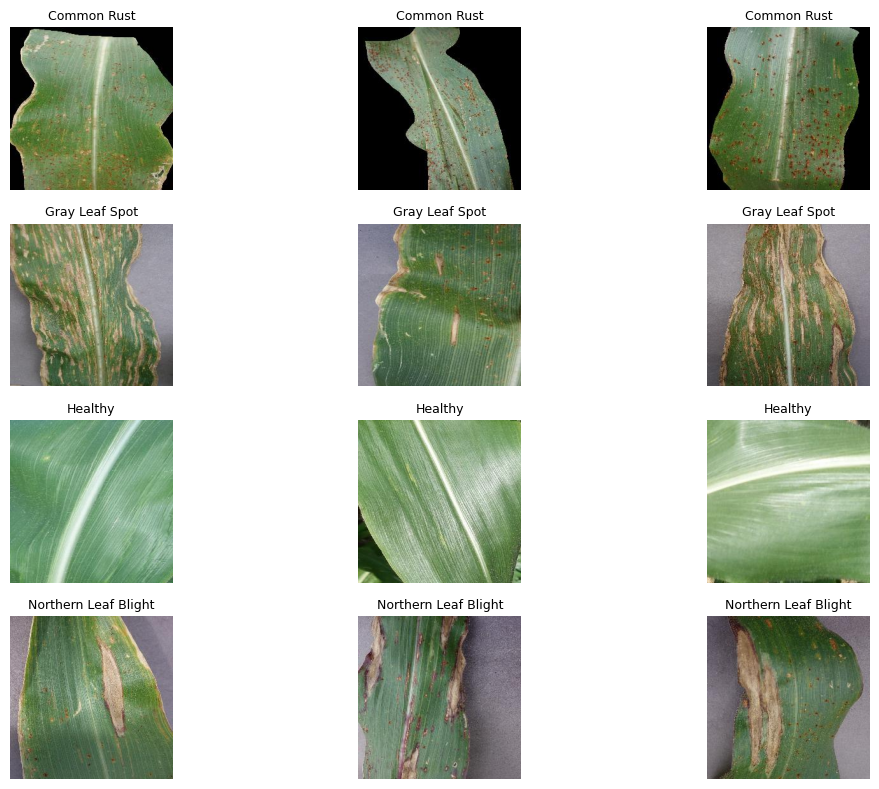

In [ ]:

sample_n = min(3, df["label"].value_counts().min())

sample_df = df.groupby(
    "label",
    group_keys=False
).sample(
    n=sample_n,
    random_state=42
)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = tf.keras.utils.load_img(row["filepath"])
    plt.subplot(4, sample_n, i + 1)
    plt.imshow(img)
    plt.title(row["label"], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 4. Split data

In [ ]:

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Training: 2696
Validation: 578
Test: 578


## 5. Import PyTorch and define preprocessing

In [12]:

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import f1_score

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

IMG_SIZE = 299
BATCH_SIZE = 32

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])


Device: cuda


## 6. PyTorch datasets and loaders

In [13]:

class_names = sorted(df["label"].unique().tolist())
class_to_index = {
    name: i for i, name in enumerate(class_names)
}

class CropDiseaseDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(
            row["filepath"]
        ).convert("RGB")

        label = class_to_index[row["label"]]

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = CropDiseaseDataset(
    train_df,
    train_transform
)

val_dataset = CropDiseaseDataset(
    val_df,
    val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Classes:", class_names)


Classes: ['Common Rust', 'Gray Leaf Spot', 'Healthy', 'Northern Leaf Blight']


## 7. Load pretrained models and replace final classifiers

In [14]:

def build_model(model_name, num_classes):

    if model_name == "ResNet50":
        model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        for param in model.parameters():
            param.requires_grad = False

        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )

    elif model_name == "DenseNet121":
        model = models.densenet121(
            weights=models.DenseNet121_Weights.DEFAULT
        )

        for param in model.parameters():
            param.requires_grad = False

        model.classifier = nn.Linear(
            model.classifier.in_features,
            num_classes
        )

    elif model_name == "InceptionV3":
        model = models.inception_v3(
            weights=models.Inception_V3_Weights.DEFAULT,
            aux_logits=True
        )

        for param in model.parameters():
            param.requires_grad = False

        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )

        if model.AuxLogits is not None:
            model.AuxLogits.fc = nn.Linear(
                model.AuxLogits.fc.in_features,
                num_classes
            )

    else:
        raise ValueError("Unknown model")

    return model.to(device)


## 8. Training and validation functions

In [15]:

criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer, model_name):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        if model_name == "InceptionV3":
            main_logits = outputs.logits
            aux_logits = outputs.aux_logits

            loss = (
                criterion(main_logits, labels)
                + 0.4 * criterion(aux_logits, labels)
            )

            preds = main_logits.argmax(dim=1)

        else:
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total
    )


def validate(model, loader):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            if hasattr(outputs, "logits"):
                outputs = outputs.logits

            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)

            running_loss += (
                loss.item() * images.size(0)
            )

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

            y_true.extend(
                labels.cpu().numpy()
            )

            y_pred.extend(
                preds.cpu().numpy()
            )

    val_loss = running_loss / total
    val_accuracy = correct / total

    val_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    return val_loss, val_accuracy, val_f1


## 9. Train and compare all three pretrained CNNs

In [16]:

MODEL_NAMES = [
    "ResNet50",
    "InceptionV3",
    "DenseNet121"
]

EPOCHS = 5

results = []
histories = {}

for model_name in MODEL_NAMES:

    print("\n" + "=" * 60)
    print("Training:", model_name)
    print("=" * 60)

    model = build_model(
        model_name,
        len(class_names)
    )

    optimizer = optim.Adam(
        filter(
            lambda p: p.requires_grad,
            model.parameters()
        ),
        lr=0.001
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_f1": []
    }

    for epoch in range(EPOCHS):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            model_name
        )

        val_loss, val_acc, val_f1 = validate(
            model,
            val_loader
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val F1: {val_f1:.4f}"
        )

    histories[model_name] = history

    results.append({
        "Model": model_name,
        "Validation Loss": history["val_loss"][-1],
        "Validation Accuracy": history["val_accuracy"][-1],
        "Weighted F1": history["val_f1"][-1]
    })

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()



Training: ResNet50
Epoch 1/5 | Train Loss: 0.6216 | Train Acc: 0.8279 | Val Loss: 0.3462 | Val Acc: 0.9187 | Val F1: 0.9098
Epoch 2/5 | Train Loss: 0.2815 | Train Acc: 0.9295 | Val Loss: 0.2387 | Val Acc: 0.9498 | Val F1: 0.9483
Epoch 3/5 | Train Loss: 0.2146 | Train Acc: 0.9403 | Val Loss: 0.1948 | Val Acc: 0.9516 | Val F1: 0.9507
Epoch 4/5 | Train Loss: 0.1885 | Train Acc: 0.9418 | Val Loss: 0.1825 | Val Acc: 0.9498 | Val F1: 0.9499
Epoch 5/5 | Train Loss: 0.1705 | Train Acc: 0.9492 | Val Loss: 0.1621 | Val Acc: 0.9516 | Val F1: 0.9492

Training: InceptionV3
Epoch 1/5 | Train Loss: 0.9072 | Train Acc: 0.7611 | Val Loss: 0.4083 | Val Acc: 0.9221 | Val F1: 0.9189
Epoch 2/5 | Train Loss: 0.4774 | Train Acc: 0.8783 | Val Loss: 0.3076 | Val Acc: 0.9187 | Val F1: 0.9130
Epoch 3/5 | Train Loss: 0.3707 | Train Acc: 0.9058 | Val Loss: 0.2339 | Val Acc: 0.9343 | Val F1: 0.9338
Epoch 4/5 | Train Loss: 0.3450 | Train Acc: 0.9062 | Val Loss: 0.2127 | Val Acc: 0.9412 | Val F1: 0.9405
Epoch 5/5 | 

100%|██████████| 30.8M/30.8M [00:00<00:00, 105MB/s]


Epoch 1/5 | Train Loss: 0.6049 | Train Acc: 0.8160 | Val Loss: 0.2881 | Val Acc: 0.9256 | Val F1: 0.9200
Epoch 2/5 | Train Loss: 0.2667 | Train Acc: 0.9203 | Val Loss: 0.2283 | Val Acc: 0.9221 | Val F1: 0.9144
Epoch 3/5 | Train Loss: 0.2124 | Train Acc: 0.9366 | Val Loss: 0.1677 | Val Acc: 0.9567 | Val F1: 0.9572
Epoch 4/5 | Train Loss: 0.1832 | Train Acc: 0.9403 | Val Loss: 0.1492 | Val Acc: 0.9585 | Val F1: 0.9587
Epoch 5/5 | Train Loss: 0.1651 | Train Acc: 0.9473 | Val Loss: 0.1398 | Val Acc: 0.9516 | Val F1: 0.9506


## 10. Results table and best model

In [17]:

results_df = pd.DataFrame(results)

results_df["Validation Accuracy (%)"] = (
    results_df["Validation Accuracy"] * 100
)

results_df["Weighted F1 (%)"] = (
    results_df["Weighted F1"] * 100
)

results_df = results_df.sort_values(
    by="Weighted F1",
    ascending=False
).reset_index(drop=True)

display(
    results_df[
        [
            "Model",
            "Validation Loss",
            "Validation Accuracy (%)",
            "Weighted F1 (%)"
        ]
    ]
)

best = results_df.iloc[0]

print("Best-performing model:", best["Model"])
print(
    f"Validation Accuracy: "
    f"{best['Validation Accuracy (%)']:.2f}%"
)
print(
    f"Weighted F1: "
    f"{best['Weighted F1 (%)']:.2f}%"
)
print(
    f"Validation Loss: "
    f"{best['Validation Loss']:.4f}"
)


,Model,Validation Loss,Validation Accuracy (%),Weighted F1 (%)
0,DenseNet121,0.139780,95.155709,95.056430
1,ResNet50,0.162120,95.155709,94.921664
2,InceptionV3,0.212644,92.733564,92.758187


Best-performing model: DenseNet121
Validation Accuracy: 95.16%
Weighted F1: 95.06%
Validation Loss: 0.1398


## 11. Comparison graphs

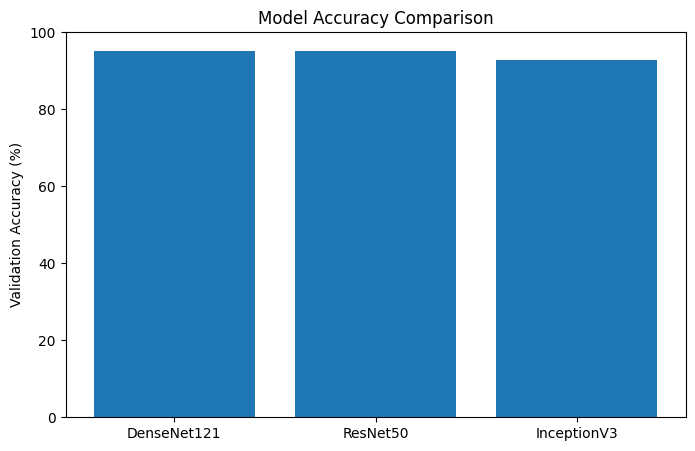

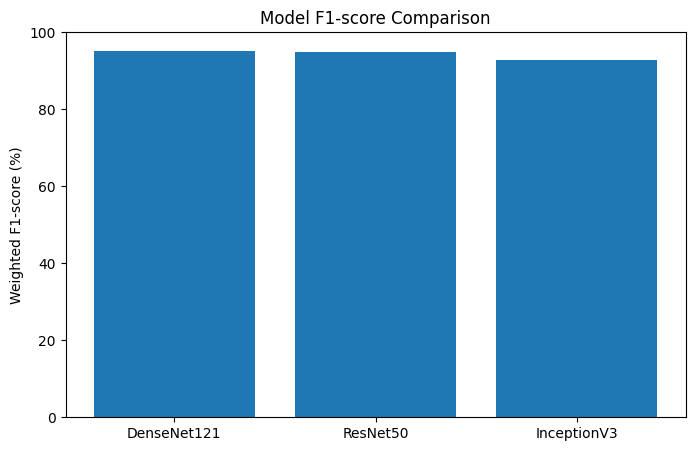

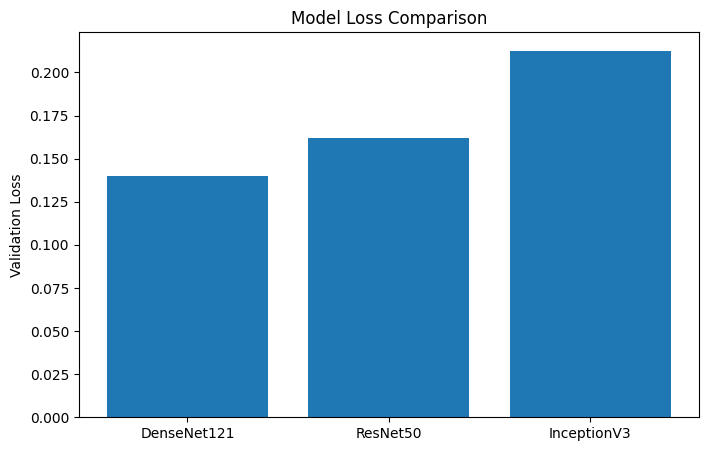

In [18]:

plt.figure(figsize=(8, 5))
plt.bar(
    results_df["Model"],
    results_df["Validation Accuracy (%)"]
)
plt.ylabel("Validation Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(
    results_df["Model"],
    results_df["Weighted F1 (%)"]
)
plt.ylabel("Weighted F1-score (%)")
plt.title("Model F1-score Comparison")
plt.ylim(0, 100)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(
    results_df["Model"],
    results_df["Validation Loss"]
)
plt.ylabel("Validation Loss")
plt.title("Model Loss Comparison")
plt.show()


# Brief Comparative Report

## Experimental setup

This experiment compared **ResNet50, InceptionV3 and DenseNet121** as transfer-learning models for four-class maize leaf disease classification: Common Rust, Gray Leaf Spot, Healthy and Northern Leaf Blight. The dataset contained 3,852 images and was divided using stratified sampling into 2,696 training images, 578 validation images and 578 test images. All images were resized to **299 × 299 pixels**, normalized using the standard ImageNet mean and standard deviation, and augmented during training using horizontal flips, small rotations and colour jitter. ImageNet-pretrained feature-extraction layers were frozen, while each final classifier was replaced and trained for the four target classes over five epochs.

## Model performance comparison

| Model | Validation Loss | Validation Accuracy | Weighted F1-score |
|---|---:|---:|---:|
| DenseNet121 | **0.1398** | **95.16%** | **95.06%** |
| ResNet50 | 0.1621 | **95.16%** | 94.92% |
| InceptionV3 | 0.2126 | 92.73% | 92.76% |

**DenseNet121 produced the best overall final-epoch result.** It tied ResNet50 for the highest validation accuracy at 95.16%, but achieved a slightly higher weighted F1-score (95.06% versus 94.92%) and the lowest validation loss (0.1398 versus 0.1621). The lower loss indicates that DenseNet121 was generally more confident in its correct predictions, while its marginally higher weighted F1-score suggests a slightly better balance between precision and recall across the four classes. Its dense feature reuse may have helped preserve fine-grained visual patterns such as lesion texture, colour and distribution.

**ResNet50 was a very close second.** Its final validation accuracy matched DenseNet121, and the difference in weighted F1-score was only about 0.13 percentage points. ResNet50 also showed stable convergence: validation loss decreased from 0.3462 to 0.1621 while validation accuracy rose from 91.87% to 95.16%. This makes ResNet50 a strong alternative when architectural simplicity, widespread deployment support or predictable residual-network behaviour is preferred.

**InceptionV3 ranked third at the final epoch**, recording 92.73% validation accuracy, a 92.76% weighted F1-score and the highest validation loss of 0.2126. It improved substantially during training and reached its best observed validation accuracy of 94.12% at epoch 4, before declining at epoch 5. This late reduction suggests mild instability or overfitting and shows that selecting the best checkpoint, rather than automatically using the last epoch, could improve its reported performance.

DenseNet121 also reached a higher intermediate result at epoch 4—95.85% validation accuracy and a 95.87% weighted F1-score—before finishing slightly lower at epoch 5. Therefore, the final-epoch table supports DenseNet121 as the winner, but the training histories also demonstrate the value of **early stopping and model checkpointing based on validation F1-score or validation loss**.

## Interpretation and limitations

The weighted F1-scores closely track the accuracy values for all three models, indicating that performance was not driven solely by the more frequent classes. Nevertheless, Gray Leaf Spot had substantially fewer images than the other categories, so weighted averages can still conceal weaker minority-class performance. A per-class classification report, confusion matrix and macro F1-score should be examined before concluding that the system performs equally well for every disease.

The differences between DenseNet121 and ResNet50 are small and come from a single train-validation split. Repeated runs with different random seeds, cross-validation or confidence intervals would be needed to establish whether DenseNet121's advantage is statistically reliable. Final model selection should also be confirmed on the untouched 578-image test set, since the validation set was used for comparison and model choice.

## Conclusion and Kenyan agricultural relevance

Based on the final validation metrics, **DenseNet121 is the preferred model**, with ResNet50 providing nearly equivalent performance and InceptionV3 trailing both. For Kenyan agriculture, a validated model could support field disease scouting, agricultural extension services and smartphone-assisted diagnosis, enabling earlier recognition of maize disease symptoms. Practical deployment would require testing and preferably fine-tuning on representative Kenyan field images captured across different counties, maize varieties, growth stages, phones, lighting conditions and backgrounds. The tool should assist—not replace—agronomic diagnosis, and low-confidence predictions should be referred to an extension officer or plant-pathology expert.